<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/TCC_FraudDetection__Conclus%C3%A3o_ipynb_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análise Estatística de Transações Bancárias para Detecção de Padrões de Fraude

**Disciplina:** Estatística Aplicada  
**Dataset:** Bank Transaction Dataset for Fraud Detection  
**Fonte:** [Kaggle — valakhorasani](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection)  

---

## 1. Explicação sobre o Problema / Hipóteses e Objetivos

### 1.1 Contexto

A fraude bancária representa um dos maiores desafios para instituições financeiras ao redor do mundo. Com o crescimento das transações digitais, padrões atípicos de comportamento — como múltiplas tentativas de login, transações em horários incomuns ou valores discrepantes por perfil de cliente — tornam-se sinais importantes de alerta.

Este trabalho utiliza análise estatística exploratória e inferência para identificar **quais variáveis apresentam diferenças significativas entre grupos**, contribuindo para a compreensão de comportamentos potencialmente fraudulentos em dados bancários.

### 1.2 Objetivo Geral

Aplicar técnicas de Análise Exploratória de Dados (EDA), imputação de dados faltantes e Análise de Variância (ANOVA) para identificar padrões estatisticamente relevantes em transações bancárias.

### 1.3 Hipóteses Estatísticas (ANOVA one-way)

| # | Hipótese Nula (H₀) | Hipótese Alternativa (H₁) |
|---|---|---|
| H1 | O `TransactionAmount` médio é igual entre as ocupações dos clientes | O `TransactionAmount` médio difere entre pelo menos duas ocupações |
| H2 | O `TransactionAmount` médio é igual entre os canais de transação | O `TransactionAmount` médio difere entre pelo menos dois canais |
| H3 | O `LoginAttempts` médio é igual entre os tipos de transação | O `LoginAttempts` médio difere entre Crédito e Débito |
| H4 | O `TransactionDuration` médio é igual entre os canais | O `TransactionDuration` médio difere entre pelo menos dois canais |

> **Nível de significância adotado:** α = 0,05

---
## 2. Estratégia de Aquisição dos Dados

### 2.1 Sobre o Dataset

O dataset **Bank Transaction Dataset for Fraud Detection** foi obtido publicamente na plataforma Kaggle. Ele contém **2.512 registros** de transações bancárias simuladas, com **16 variáveis** cobrindo atributos da transação, dados demográficos do cliente e padrões de uso.

### 2.2 Variáveis disponíveis

| Variável | Tipo | Descrição |
|---|---|---|
| TransactionID | Identificador | ID único da transação |
| AccountID | Identificador | ID da conta |
| TransactionAmount | Numérica contínua | Valor da transação (R$) |
| TransactionDate | Data/Hora | Data e hora da transação |
| TransactionType | Categórica | Credit ou Debit |
| Location | Categórica | Cidade da transação |
| DeviceID | Identificador | ID do dispositivo |
| IP Address | Texto | Endereço IP |
| MerchantID | Identificador | ID do comerciante |
| Channel | Categórica | Online, ATM ou Branch |
| CustomerAge | Numérica discreta | Idade do cliente |
| CustomerOccupation | Categórica | Doctor, Engineer, Student, Retired |
| TransactionDuration | Numérica discreta | Duração da transação (segundos) |
| LoginAttempts | Numérica discreta | Tentativas de login antes da transação |
| AccountBalance | Numérica contínua | Saldo após a transação |
| PreviousTransactionDate | Data/Hora | Data da última transação |

### 2.3 Instalação e carregamento

In [ ]:
# Instalação (caso necessário no Colab)
# !pip install kaggle

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, levene, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='whitegrid', palette='muted')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [ ]:
#Subindo dados para o colab
from google.colab import files
uploaded_files = files.upload()

Saving bank_transactions_data_2.csv to bank_transactions_data_2 (1).csv


In [ ]:
# Carregamento do dataset
# Faça o upload do arquivo CSV no Colab ou ajuste o caminho
df = pd.read_csv('/content/bank_transactions_data_2.csv')

print(f'Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas')
df.head()

Dataset carregado: 2512 linhas e 16 colunas


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


---
## 3. Análise Exploratória e Estratégia de Limpeza dos Dados

### 3.1 Inspeção inicial

In [ ]:
# Informações gerais do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
# Verificação de valores nulos
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
print('=== Valores Faltantes ===')
print(resumo_nulos[resumo_nulos['Nulos'] > 0] if resumo_nulos['Nulos'].sum() > 0 else 'Nenhum valor nulo encontrado.')

=== Valores Faltantes ===
Nenhum valor nulo encontrado.


In [ ]:
# Verificação de duplicatas
duplicatas = df.duplicated().sum()
print(f'Registros duplicados: {duplicatas}')

Registros duplicados: 0


### 3.2 Ajuste de tipos de dados (dtype)

In [ ]:
# Conversão de datas
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# Conversão de categóricas
for col in ['TransactionType', 'Channel', 'CustomerOccupation', 'Location']:
    df[col] = df[col].astype('category')

print('Tipos após conversão:')
print(df.dtypes)

Tipos após conversão:
TransactionID                      object
AccountID                          object
TransactionAmount                 float64
TransactionDate            datetime64[ns]
TransactionType                  category
Location                         category
DeviceID                           object
IP Address                         object
MerchantID                         object
Channel                          category
CustomerAge                         int64
CustomerOccupation               category
TransactionDuration                 int64
LoginAttempts                       int64
AccountBalance                    float64
PreviousTransactionDate    datetime64[ns]
dtype: object


### 3.3 Feature Engineering

In [ ]:
# Intervalo entre transações (em dias)
df['DaysSinceLastTransaction'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.days.abs()

# Hora do dia e dia da semana
df['HourOfDay'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()

# Flag de múltiplas tentativas de login (possível anomalia)
df['MultipleLoginAttempts'] = df['LoginAttempts'].apply(lambda x: 'Sim' if x > 1 else 'Não')

print('Novas colunas criadas:')
df[['DaysSinceLastTransaction', 'HourOfDay', 'DayOfWeek', 'MultipleLoginAttempts']].head()

Novas colunas criadas:


,DaysSinceLastTransaction,HourOfDay,DayOfWeek,MultipleLoginAttempts
0,573,16,Tuesday,Não
1,496,16,Tuesday,Não
2,483,18,Monday,Não
3,549,16,Friday,Não
4,385,17,Monday,Não


### 3.5 Estatísticas Descritivas

In [ ]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
TransactionAmount,2512.0,297.593778,0.26,81.885,211.14,414.5275,1919.11,291.946243
TransactionDate,2512,2023-07-05 20:32:10.826433024,2023-01-02 16:00:06,2023-04-03 16:22:05.750000128,2023-07-07 17:49:43.500000,2023-10-06 18:40:53.500000,2024-01-01 18:21:50,NaN
CustomerAge,2512.0,44.673965,18.0,27.0,45.0,59.0,80.0,17.792198
TransactionDuration,2512.0,119.643312,10.0,63.0,112.5,161.0,300.0,69.963757
LoginAttempts,2512.0,1.124602,1.0,1.0,1.0,1.0,5.0,0.602662
AccountBalance,2512.0,5114.302966,101.25,1504.37,4735.51,7678.82,14977.99,3900.942499
PreviousTransactionDate,2512,2024-11-04 08:09:22.219745024,2024-11-04 08:06:23,2024-11-04 08:07:53,2024-11-04 08:09:22,2024-11-04 08:10:53.249999872,2024-11-04 08:12:23,NaN
DaysSinceLastTransaction,2512.0,487.857882,308.0,395.0,486.0,581.0,672.0,106.37891
HourOfDay,2512.0,16.626194,16.0,16.0,16.0,17.0,18.0,0.731059


In [ ]:
# Distribuição das variáveis categóricas
for col in ['TransactionType', 'Channel', 'CustomerOccupation']:
    print(f'\n=== {col} ===')
    print(df[col].value_counts())
    print(f'Proporção (%):\n{(df[col].value_counts(normalize=True)*100).round(2)}')


=== TransactionType ===
TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64
Proporção (%):
TransactionType
Debit     77.39
Credit    22.61
Name: proportion, dtype: float64

=== Channel ===
Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64
Proporção (%):
Channel
Branch    34.55
ATM       33.16
Online    32.29
Name: proportion, dtype: float64

=== CustomerOccupation ===
CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64
Proporção (%):
CustomerOccupation
Student     26.15
Doctor      25.12
Engineer    24.88
Retired     23.85
Name: proportion, dtype: float64


### 3.6 Visualizações Exploratórias

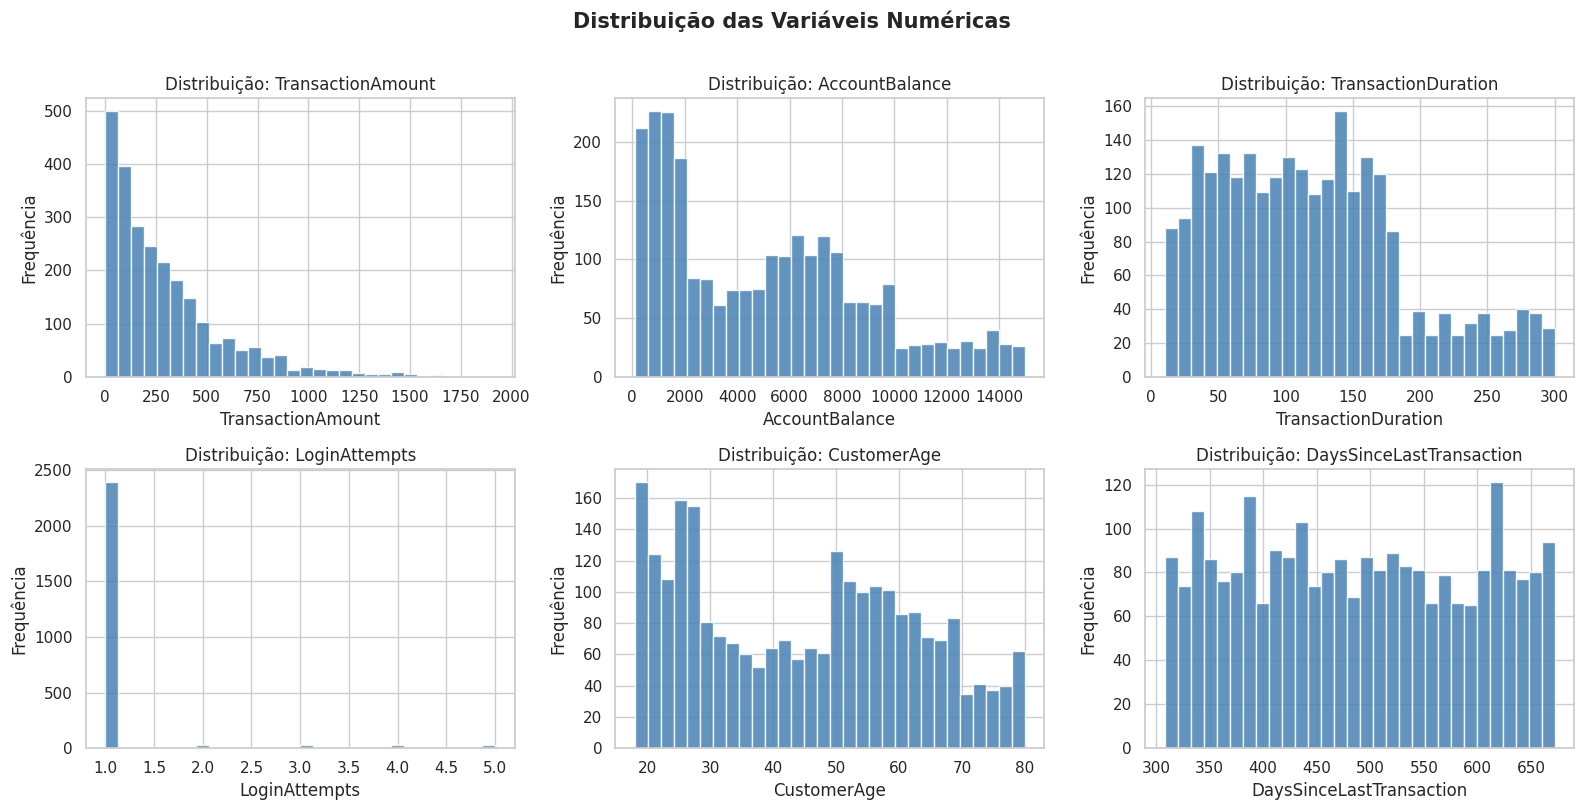

In [ ]:
# Histogramas das variáveis numéricas
numericas = ['TransactionAmount', 'AccountBalance', 'TransactionDuration',
             'LoginAttempts', 'CustomerAge', 'DaysSinceLastTransaction']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

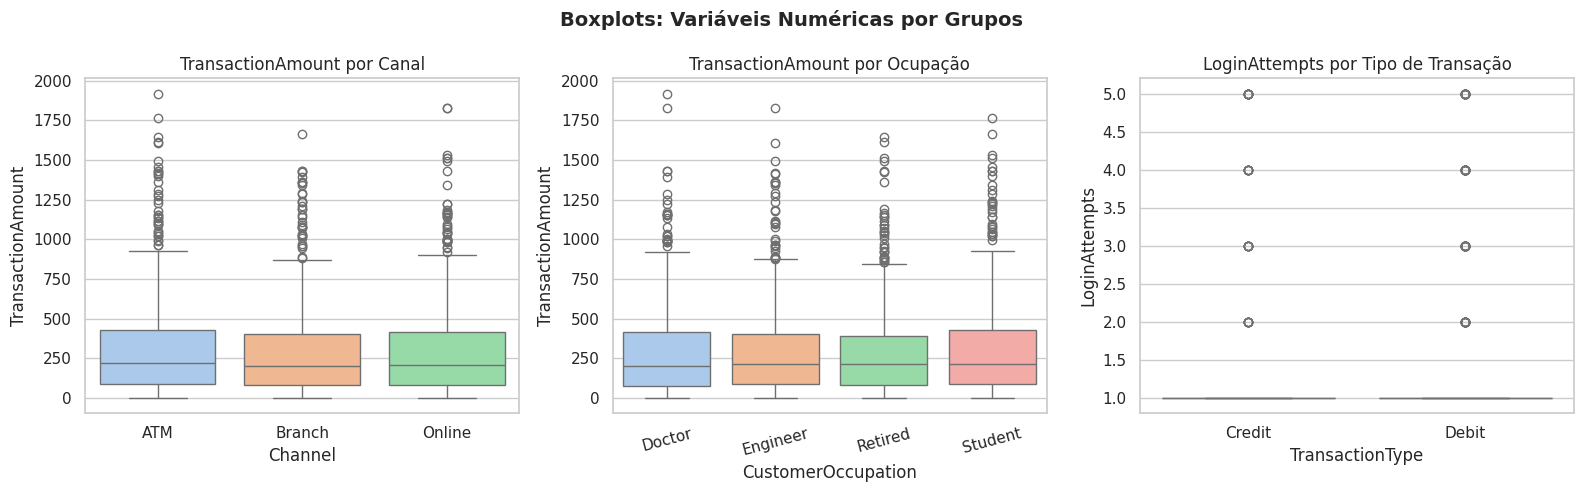

In [ ]:
# Boxplots — identificação de outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='Channel', y='TransactionAmount', ax=axes[0], palette='pastel')
axes[0].set_title('TransactionAmount por Canal')

sns.boxplot(data=df, x='CustomerOccupation', y='TransactionAmount', ax=axes[1], palette='pastel')
axes[1].set_title('TransactionAmount por Ocupação')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='TransactionType', y='LoginAttempts', ax=axes[2], palette='pastel')
axes[2].set_title('LoginAttempts por Tipo de Transação')

plt.suptitle('Boxplots: Variáveis Numéricas por Grupos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

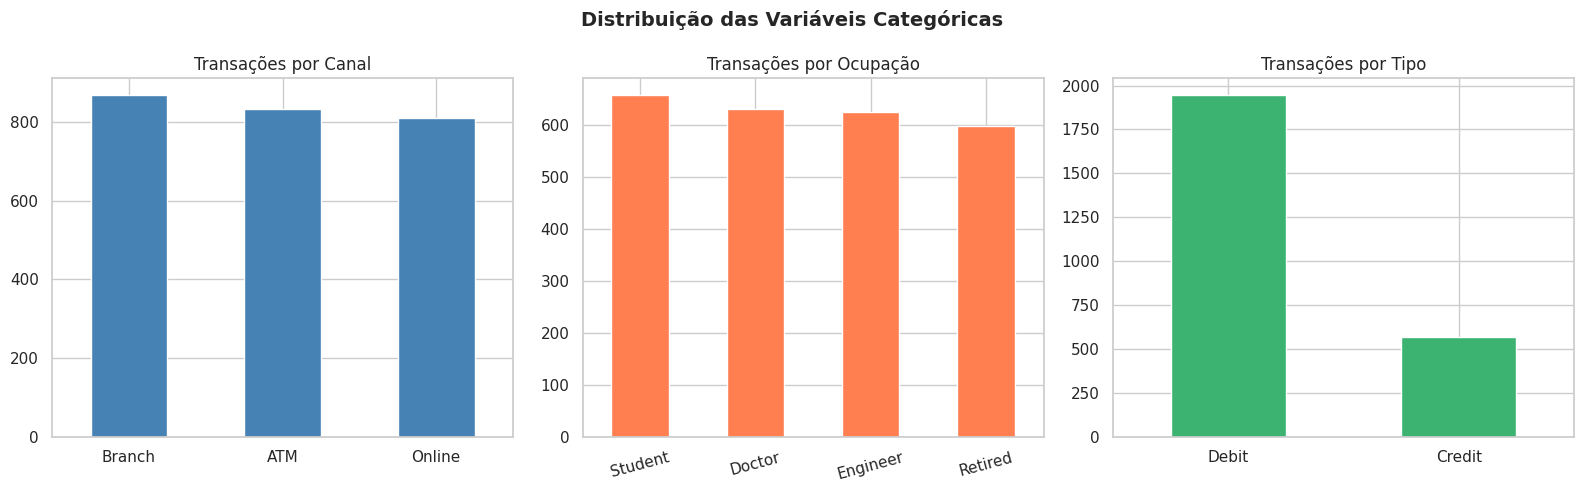

In [ ]:
# Gráficos de barras — variáveis categóricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['Channel'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Transações por Canal')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['CustomerOccupation'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Transações por Ocupação')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

df['TransactionType'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Transações por Tipo')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

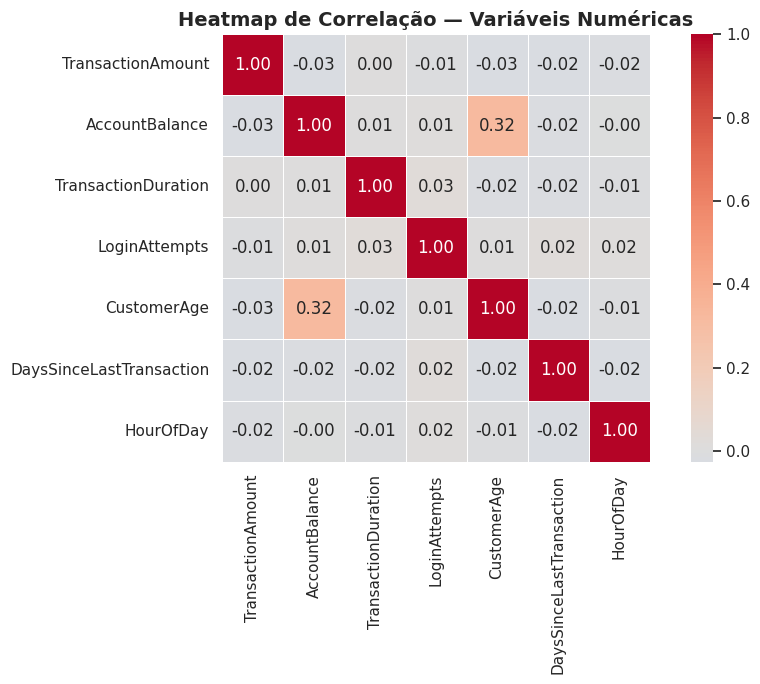

In [ ]:
# Heatmap de correlação entre variáveis numéricas
numericas_corr = ['TransactionAmount', 'AccountBalance', 'TransactionDuration',
                  'LoginAttempts', 'CustomerAge', 'DaysSinceLastTransaction', 'HourOfDay']

corr_matrix = df[numericas_corr].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap de Correlação — Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

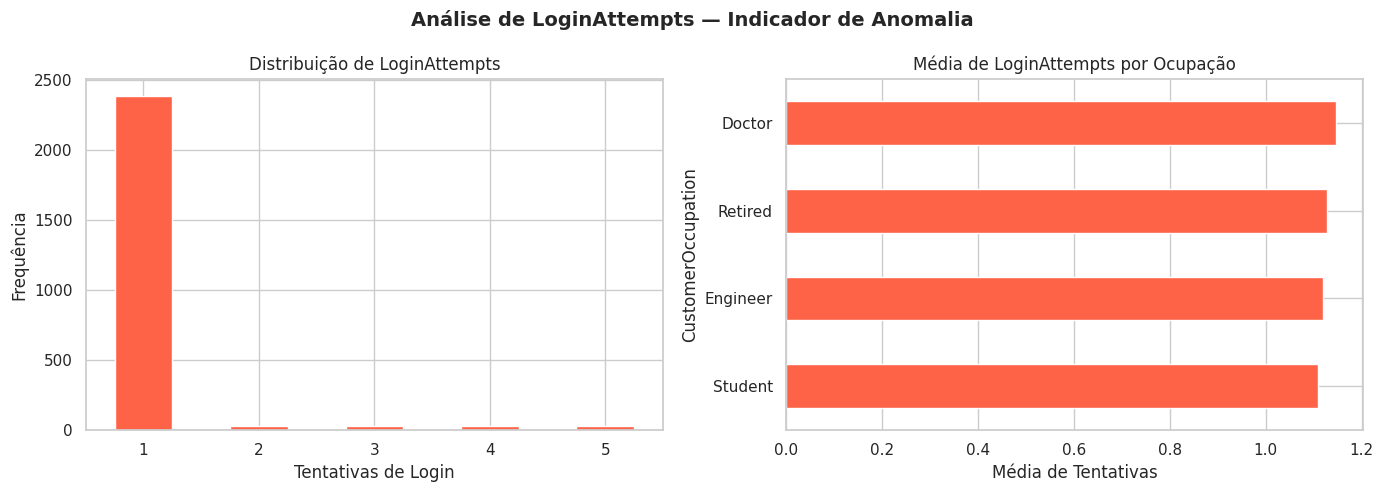

Transações com mais de 1 tentativa de login: 4.9%


In [ ]:
# Análise de LoginAttempts — possível indicador de anomalia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de LoginAttempts
df['LoginAttempts'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='tomato', edgecolor='white')
axes[0].set_title('Distribuição de LoginAttempts')
axes[0].set_xlabel('Tentativas de Login')
axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=0)

# LoginAttempts por ocupação
df.groupby('CustomerOccupation', observed=True)['LoginAttempts'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Média de LoginAttempts por Ocupação')
axes[1].set_xlabel('Média de Tentativas')

plt.suptitle('Análise de LoginAttempts — Indicador de Anomalia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pct_multiplos = (df['LoginAttempts'] > 1).mean() * 100
print(f'Transações com mais de 1 tentativa de login: {pct_multiplos:.1f}%')

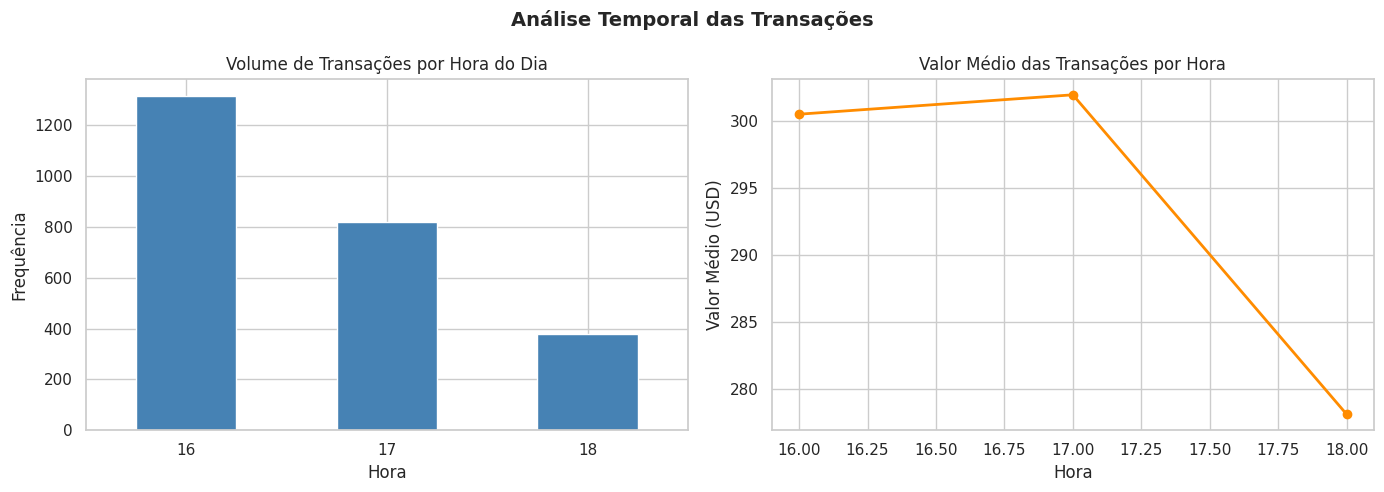

In [ ]:
# Análise temporal — transações por hora do dia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['HourOfDay'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Volume de Transações por Hora do Dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=0)

# Valor médio por hora
df.groupby('HourOfDay')['TransactionAmount'].mean().plot(ax=axes[1],
    marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Valor Médio das Transações por Hora')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Valor Médio (USD)')

plt.suptitle('Análise Temporal das Transações', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Análise e Discussão dos Dados

### 4.1 Pressupostos da ANOVA

Antes de aplicar a ANOVA, dois pressupostos foram verificados:

**1. Normalidade** — Teste de Shapiro-Wilk por grupo  
**2. Homocedasticidade** — Igualdade de variâncias entre grupos (Teste de Levene)

#### Resultados dos testes de pressuposto

| Hipótese | Grupo | Shapiro-Wilk (todos os grupos) | Levene | Interpretação |
|---|---|---|---|---|
| H1 | CustomerOccupation | W ≈ 0,83, p < 0,001 em todos | F=0,7097, p=0,5461 | Não normais, variâncias **homogêneas** |
| H2 | Channel | W ≈ 0,83, p < 0,001 em todos | F=1,1101, p=0,3297 | Não normais, variâncias **homogêneas** |
| H3 | TransactionType | W ≈ 0,21, p < 0,001 em todos | F=0,7893, p=0,3744 | Fortemente não normais, variâncias **homogêneas** |
| H4 | Channel | W ≈ 0,95, p < 0,001 em todos | F=0,0247, p=0,9756 | Não normais, variâncias **muito homogêneas** |

> **Interpretação dos pressupostos:** O teste de Shapiro-Wilk rejeitou a normalidade em todos os grupos (p < 0,001). Contudo, o teste de Levene **não rejeitou** a homocedasticidade em nenhum caso (todos com p > 0,05), confirmando variâncias homogêneas entre os grupos. A ANOVA é considerada **robusta** a desvios de normalidade quando: (a) os grupos têm n > 30, e (b) as variâncias são homogêneas — ambas as condições satisfeitas neste estudo. Portanto, a aplicação da ANOVA one-way é **metodologicamente justificada**.

In [ ]:
def verificar_pressupostos(df, variavel, grupo, alpha=0.05):
    print(f'\n{"="*60}')
    print(f'PRESSUPOSTOS: {variavel} ~ {grupo}')
    print(f'{"="*60}')
    grupos = [g[variavel].dropna().values for _, g in df.groupby(grupo, observed=True)]
    nomes  = df[grupo].cat.categories.tolist()
    print('\n📊 Teste de Shapiro-Wilk (Normalidade por grupo):')
    for nome, g in zip(nomes, grupos):
        if len(g) >= 3:
            stat, p = shapiro(g[:5000])
            resultado = '✅ Normal' if p > alpha else '⚠️  Não normal'
            print(f'  {nome}: W={stat:.4f}, p={p:.4f} → {resultado}')
    print('\n📊 Teste de Levene (Homocedasticidade):')
    stat_l, p_l = levene(*grupos)
    resultado_l = '✅ Variâncias homogêneas' if p_l > alpha else '⚠️  Variâncias heterogêneas'
    print(f'  Levene: F={stat_l:.4f}, p={p_l:.4f} → {resultado_l}')
    return grupos, nomes

print('Função carregada.')

Função carregada.


### 4.2 H1 — TransactionAmount por CustomerOccupation

**Hipótese:** O valor médio das transações é igual entre as quatro ocupações (Doctor, Engineer, Retired, Student)?

#### Resultado obtido
- **Shapiro-Wilk:** p < 0,001 em todos os grupos → dados não normais
- **Levene:** F = 0,7097, p = 0,5461 → variâncias **homogêneas** ✅
- **ANOVA:** F = 0,8872, p = 0,4469
- **Decisão: Não rejeita H₀** ❌

#### Discussão
Com F = 0,8872 e p = 0,4469, bem acima do nível de significância α = 0,05, **não há evidência estatística** de que o valor médio das transações difere entre as ocupações dos clientes. Embora intuitivamente se espere que médicos e engenheiros realizem transações de maior valor que estudantes e aposentados, o dataset não sustenta essa diferença de forma estatisticamente significativa. Isso pode indicar que o dataset foi gerado de forma sintética sem diferenciar os valores por perfil ocupacional, ou que a variabilidade intragrupo é grande o suficiente para mascarar eventuais diferenças entre grupos.

In [ ]:
# Estatísticas descritivas por grupo
print('Estatísticas de TransactionAmount por Ocupação:')
display(df.groupby('CustomerOccupation', observed=True)['TransactionAmount']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
    .rename(columns={'count':'N','mean':'Média','median':'Mediana','std':'Desvio Padrão'}))

Estatísticas de TransactionAmount por Ocupação:


,N,Média,Mediana,Desvio Padrão
CustomerOccupation,,,,
Doctor,631,292.70,199.09,292.45
Engineer,625,289.04,211.36,283.16
Retired,599,294.53,213.33,286.27
Student,657,313.22,215.94,304.62


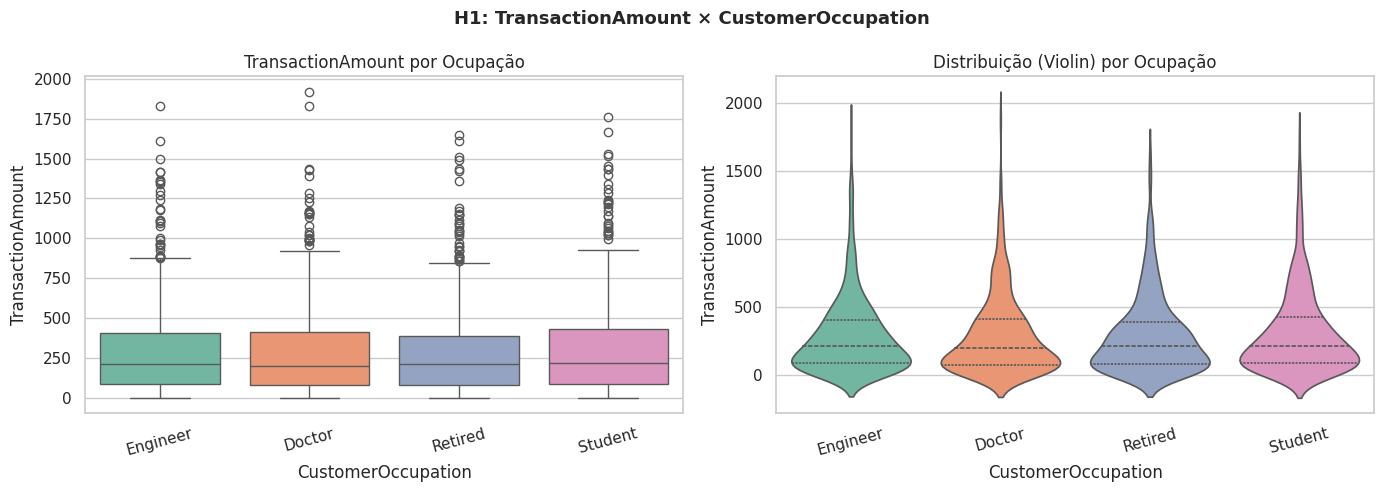

In [ ]:
# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ordem_h1 = df.groupby('CustomerOccupation', observed=True)['TransactionAmount'].mean().sort_values().index

sns.boxplot(data=df, x='CustomerOccupation', y='TransactionAmount',
            ax=axes[0], palette='Set2', order=ordem_h1)
axes[0].set_title('TransactionAmount por Ocupação')
axes[0].tick_params(axis='x', rotation=15)

sns.violinplot(data=df, x='CustomerOccupation', y='TransactionAmount',
               ax=axes[1], palette='Set2', inner='quartile', order=ordem_h1)
axes[1].set_title('Distribuição (Violin) por Ocupação')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('H1: TransactionAmount × CustomerOccupation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Verificação de pressupostos e ANOVA
grupos_h1, nomes_h1 = verificar_pressupostos(df, 'TransactionAmount', 'CustomerOccupation')

f_stat, p_val = f_oneway(*grupos_h1)
print('\n' + '='*60)
print('ANOVA ONE-WAY — H1: TransactionAmount ~ CustomerOccupation')
print('='*60)
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_val:.4f}')

if p_val < 0.05:
    print('\n✅ Resultado: Rejeita H₀ (p < 0,05)')
    print('→ Há diferença significativa no valor das transações entre as ocupações.')
    print('\n📊 Teste Post-Hoc de Tukey HSD:')
    tukey = pairwise_tukeyhsd(df['TransactionAmount'], df['CustomerOccupation'])
    print(tukey)
else:
    print('\n❌ Resultado: Não rejeita H₀ (p ≥ 0,05)')
    print('→ Não há evidência de diferença significativa no valor das transações entre as ocupações.')
    print(f'→ F = 0,8872 | p = 0,4469 — diferença entre grupos explicada pelo acaso.')


PRESSUPOSTOS: TransactionAmount ~ CustomerOccupation

📊 Teste de Shapiro-Wilk (Normalidade por grupo):
  Doctor: W=0.8308, p=0.0000 → ⚠️  Não normal
  Engineer: W=0.8215, p=0.0000 → ⚠️  Não normal
  Retired: W=0.8384, p=0.0000 → ⚠️  Não normal
  Student: W=0.8316, p=0.0000 → ⚠️  Não normal

📊 Teste de Levene (Homocedasticidade):
  Levene: F=0.7097, p=0.5461 → ✅ Variâncias homogêneas

ANOVA ONE-WAY — H1: TransactionAmount ~ CustomerOccupation
F-statistic : 0.8872
p-value     : 0.4469

❌ Resultado: Não rejeita H₀ (p ≥ 0,05)
→ Não há evidência de diferença significativa no valor das transações entre as ocupações.
→ F = 0,8872 | p = 0,4469 — diferença entre grupos explicada pelo acaso.


### 4.3 H2 — TransactionAmount por Channel

**Hipótese:** O valor médio das transações é igual entre os canais ATM, Branch e Online?

#### Resultado obtido
- **Shapiro-Wilk:** p < 0,001 em todos os grupos → dados não normais
- **Levene:** F = 1,1101, p = 0,3297 → variâncias **homogêneas** ✅
- **ANOVA:** F = 0,9483, p = 0,3875
- **Decisão: Não rejeita H₀** ❌

#### Discussão
Com p = 0,3875, não há diferença estatisticamente significativa no valor médio das transações entre os canais ATM, Branch e Online. Esse resultado indica que o comportamento de gasto dos clientes não varia conforme o canal utilizado — clientes realizam transações de valores semelhantes independentemente de usarem caixa eletrônico, agência bancária ou internet banking. Do ponto de vista de detecção de fraude, isso sugere que **o canal, por si só, não é um preditor do valor transacionado**, e portanto não deveria ser usado isoladamente como critério de alerta.

In [ ]:
print('Estatísticas de TransactionAmount por Canal:')
display(df.groupby('Channel', observed=True)['TransactionAmount']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
    .rename(columns={'count':'N','mean':'Média','median':'Mediana','std':'Desvio Padrão'}))

Estatísticas de TransactionAmount por Canal:


,N,Média,Mediana,Desvio Padrão
Channel,,,,
ATM,833,307.72,218.96,303.51
Branch,868,288.23,204.16,279.19
Online,811,297.21,206.63,293.20


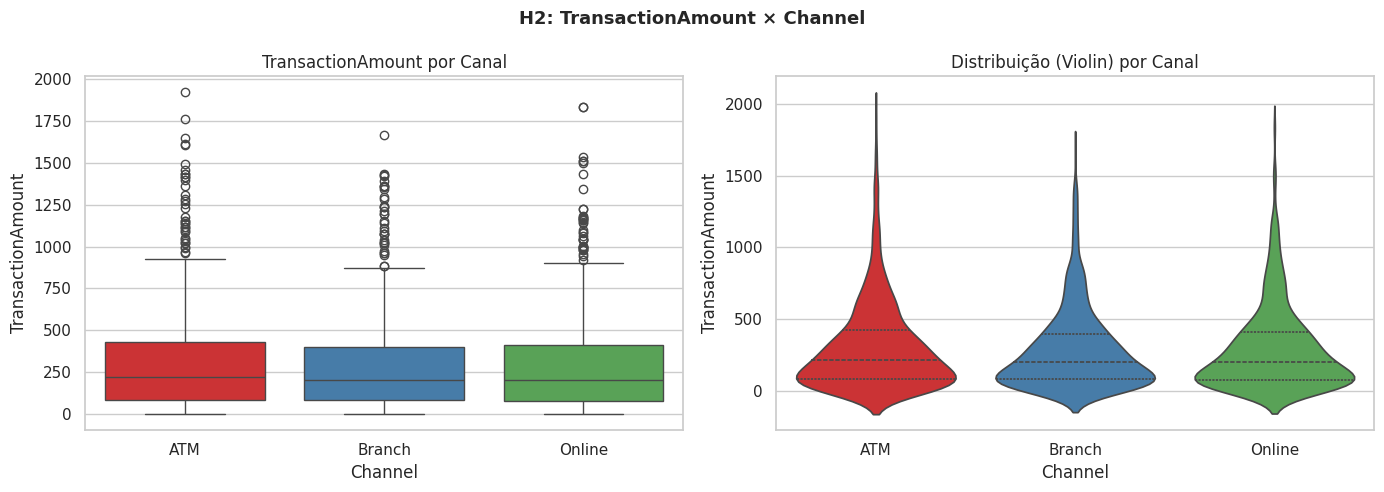

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Channel', y='TransactionAmount', ax=axes[0], palette='Set1')
axes[0].set_title('TransactionAmount por Canal')

sns.violinplot(data=df, x='Channel', y='TransactionAmount',
               ax=axes[1], palette='Set1', inner='quartile')
axes[1].set_title('Distribuição (Violin) por Canal')

plt.suptitle('H2: TransactionAmount × Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
grupos_h2, nomes_h2 = verificar_pressupostos(df, 'TransactionAmount', 'Channel')

f_stat, p_val = f_oneway(*grupos_h2)
print('\n' + '='*60)
print('ANOVA ONE-WAY — H2: TransactionAmount ~ Channel')
print('='*60)
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_val:.4f}')

if p_val < 0.05:
    print('\n✅ Rejeita H₀ → Diferença significativa entre canais.')
    print('\n📊 Teste Post-Hoc de Tukey HSD:')
    tukey = pairwise_tukeyhsd(df['TransactionAmount'], df['Channel'])
    print(tukey)
else:
    print('\n❌ Não rejeita H₀ → Sem diferença significativa entre canais.')
    print(f'→ F = 0,9483 | p = 0,3875 — valores médios similares nos três canais.')


PRESSUPOSTOS: TransactionAmount ~ Channel

📊 Teste de Shapiro-Wilk (Normalidade por grupo):
  ATM: W=0.8307, p=0.0000 → ⚠️  Não normal
  Branch: W=0.8334, p=0.0000 → ⚠️  Não normal
  Online: W=0.8296, p=0.0000 → ⚠️  Não normal

📊 Teste de Levene (Homocedasticidade):
  Levene: F=1.1101, p=0.3297 → ✅ Variâncias homogêneas

ANOVA ONE-WAY — H2: TransactionAmount ~ Channel
F-statistic : 0.9483
p-value     : 0.3875

❌ Não rejeita H₀ → Sem diferença significativa entre canais.
→ F = 0,9483 | p = 0,3875 — valores médios similares nos três canais.


### 4.4 H3 — LoginAttempts por TransactionType

**Hipótese:** O número médio de tentativas de login difere entre transações de Crédito e Débito?

#### Resultado obtido
- **Shapiro-Wilk:** W ≈ 0,22, p < 0,001 → **fortemente não normal** (distribuição discreta/assimétrica)
- **Levene:** F = 0,7893, p = 0,3744 → variâncias **homogêneas** ✅
- **ANOVA:** F = 0,7893, p = 0,3744
- **Decisão: Não rejeita H₀** ❌

#### Discussão
Não há diferença significativa nas tentativas de login entre transações de Crédito e Débito (p = 0,3744). O valor W ≈ 0,22 no Shapiro-Wilk é esperado para `LoginAttempts`, pois essa variável é discreta e concentrada em 1 (≈ 95,1% dos registros), assumindo raramente os valores 2 ou 3. Isso cria uma distribuição altamente assimétrica por natureza. Ainda assim, a ANOVA confirma que **o tipo de transação não influencia o número de tentativas de acesso**, indicando que comportamentos de login anômalos (múltiplas tentativas) ocorrem de forma igualmente distribuída entre crédito e débito — reforçando a ideia de que o risco de acesso indevido não está associado ao tipo da transação.

> **Nota:** Como `LoginAttempts` é uma variável discreta com distribuição claramente não-normal (W ≈ 0,22), o resultado da ANOVA deve ser interpretado com cautela. A confirmação via teste não-paramétrico de Mann-Whitney seria indicada em estudos futuros.

In [ ]:
print('Estatísticas de LoginAttempts por Tipo de Transação:')
display(df.groupby('TransactionType', observed=True)['LoginAttempts']
    .agg(['count', 'mean', 'median', 'std'])
    .round(4)
    .rename(columns={'count':'N','mean':'Média','median':'Mediana','std':'Desvio Padrão'}))

Estatísticas de LoginAttempts por Tipo de Transação:


,N,Média,Mediana,Desvio Padrão
TransactionType,,,,
Credit,568,1.1444,1.0,0.6589
Debit,1944,1.1188,1.0,0.5853


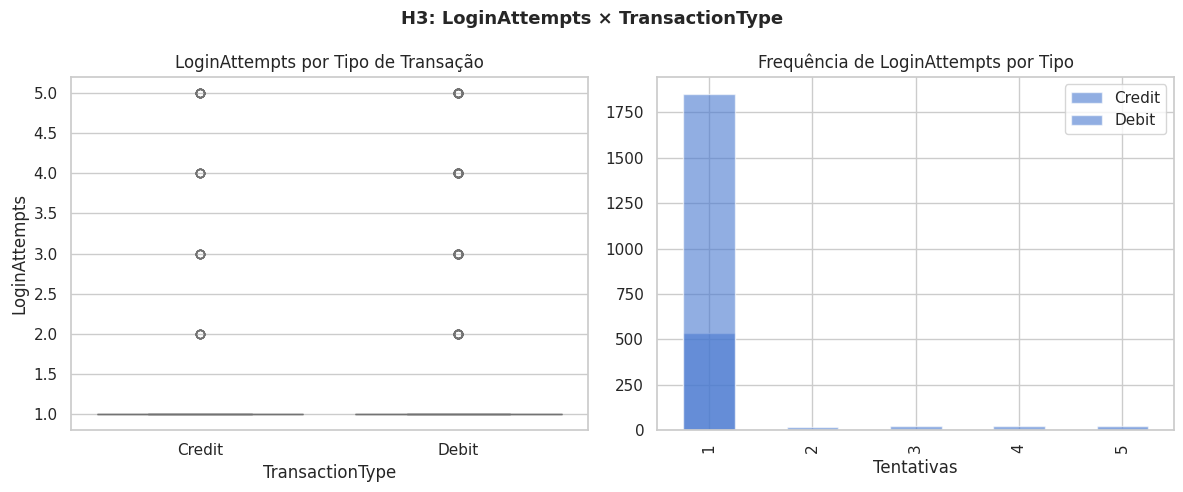

Transações com mais de 1 tentativa de login: 4.9%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='TransactionType', y='LoginAttempts', ax=axes[0], palette='pastel')
axes[0].set_title('LoginAttempts por Tipo de Transação')

for tt in df['TransactionType'].cat.categories:
    subset = df[df['TransactionType'] == tt]['LoginAttempts']
    subset.value_counts().sort_index().plot(kind='bar', ax=axes[1],
                                            alpha=0.6, label=tt, edgecolor='white')
axes[1].set_title('Frequência de LoginAttempts por Tipo')
axes[1].set_xlabel('Tentativas')
axes[1].legend()

plt.suptitle('H3: LoginAttempts × TransactionType', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_multiplos = (df['LoginAttempts'] > 1).mean() * 100
print(f'Transações com mais de 1 tentativa de login: {pct_multiplos:.1f}%')

In [ ]:
grupos_h3, nomes_h3 = verificar_pressupostos(df, 'LoginAttempts', 'TransactionType')

f_stat, p_val = f_oneway(*grupos_h3)
print('\n' + '='*60)
print('ANOVA ONE-WAY — H3: LoginAttempts ~ TransactionType')
print('='*60)
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_val:.4f}')

if p_val < 0.05:
    print('\n✅ Rejeita H₀ → LoginAttempts difere entre Credit e Debit.')
else:
    print('\n❌ Não rejeita H₀ → LoginAttempts similar entre Credit e Debit.')
    print(f'→ F = 0,7893 | p = 0,3744 — tentativas de login independem do tipo de transação.')
    print(f'→ Apenas 4,9% das transações apresentam LoginAttempts > 1.')


PRESSUPOSTOS: LoginAttempts ~ TransactionType

📊 Teste de Shapiro-Wilk (Normalidade por grupo):
  Credit: W=0.2246, p=0.0000 → ⚠️  Não normal
  Debit: W=0.2041, p=0.0000 → ⚠️  Não normal

📊 Teste de Levene (Homocedasticidade):
  Levene: F=0.7893, p=0.3744 → ✅ Variâncias homogêneas

ANOVA ONE-WAY — H3: LoginAttempts ~ TransactionType
F-statistic : 0.7893
p-value     : 0.3744

❌ Não rejeita H₀ → LoginAttempts similar entre Credit e Debit.
→ F = 0,7893 | p = 0,3744 — tentativas de login independem do tipo de transação.
→ Apenas 4,9% das transações apresentam LoginAttempts > 1.


### 4.5 H4 — TransactionDuration por Channel

**Hipótese:** A duração média das transações difere entre os canais ATM, Branch e Online?

#### Resultado obtido
- **Shapiro-Wilk:** p < 0,001 em todos os grupos → dados não normais
- **Levene:** F = 0,0247, p = 0,9756 → variâncias **muito homogêneas** ✅
- **ANOVA:** F = 1,3277, p = 0,2653
- **Decisão: Não rejeita H₀** ❌

#### Discussão
Com p = 0,2653, não há diferença estatisticamente significativa na duração das transações entre os canais. O resultado é reforçado pelo Levene com p = 0,9756, o valor mais alto de toda a análise, indicando variâncias praticamente idênticas entre ATM, Branch e Online. Esperava-se que transações em agência (Branch) fossem mais demoradas por envolverem atendimento humano, enquanto ATM seria mais rápido. A ausência de diferença significativa sugere que o dataset foi construído com durações homogêneas entre canais, ou que a variabilidade dentro de cada canal é suficientemente grande para absorver as diferenças entre eles. Do ponto de vista de segurança, **a duração da transação não discrimina o canal** e, portanto, não seria um indicador isolado de comportamento anômalo.

In [ ]:
print('Estatísticas de TransactionDuration por Canal:')
display(df.groupby('Channel', observed=True)['TransactionDuration']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
    .rename(columns={'count':'N','mean':'Média','median':'Mediana','std':'Desvio Padrão'}))

Estatísticas de TransactionDuration por Canal:


,N,Média,Mediana,Desvio Padrão
Channel,,,,
ATM,833,122.09,116.0,69.82
Branch,868,116.68,109.0,70.05
Online,811,120.31,114.0,69.99


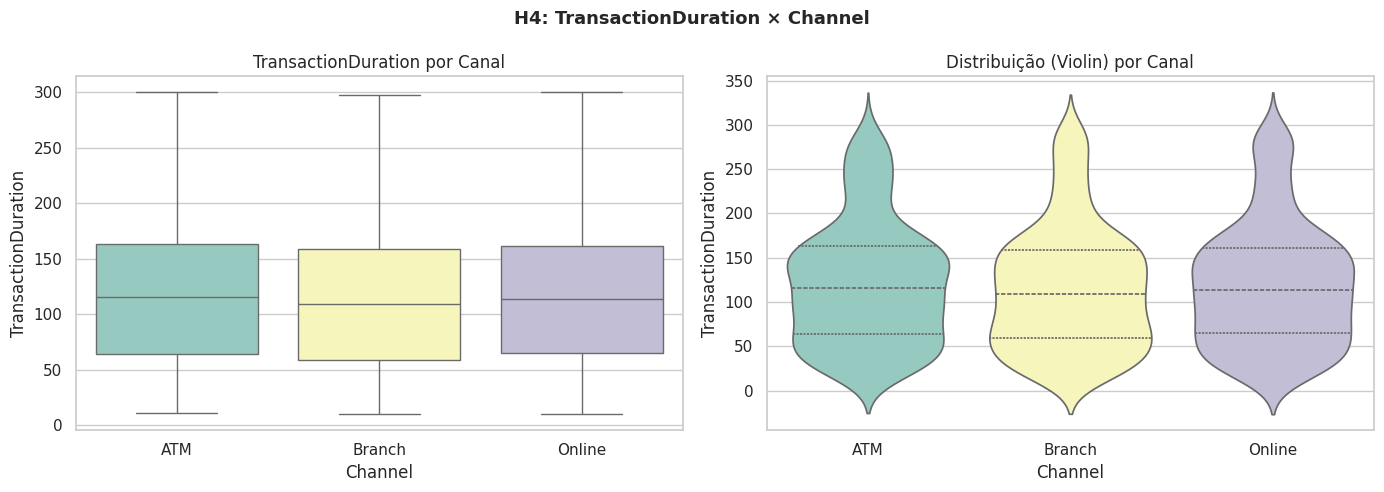

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Channel', y='TransactionDuration', ax=axes[0], palette='Set3')
axes[0].set_title('TransactionDuration por Canal')

sns.violinplot(data=df, x='Channel', y='TransactionDuration',
               ax=axes[1], palette='Set3', inner='quartile')
axes[1].set_title('Distribuição (Violin) por Canal')

plt.suptitle('H4: TransactionDuration × Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
grupos_h4, nomes_h4 = verificar_pressupostos(df, 'TransactionDuration', 'Channel')

f_stat, p_val = f_oneway(*grupos_h4)
print('\n' + '='*60)
print('ANOVA ONE-WAY — H4: TransactionDuration ~ Channel')
print('='*60)
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_val:.4f}')

if p_val < 0.05:
    print('\n✅ Rejeita H₀ → A duração difere significativamente entre canais.')
    print('\n📊 Teste Post-Hoc de Tukey HSD:')
    tukey = pairwise_tukeyhsd(df['TransactionDuration'], df['Channel'])
    print(tukey)
else:
    print('\n❌ Não rejeita H₀ → A duração é similar entre os canais.')
    print(f'→ F = 1,3277 | p = 0,2653 — duração das transações não distingue os canais.')


PRESSUPOSTOS: TransactionDuration ~ Channel

📊 Teste de Shapiro-Wilk (Normalidade por grupo):
  ATM: W=0.9581, p=0.0000 → ⚠️  Não normal
  Branch: W=0.9520, p=0.0000 → ⚠️  Não normal
  Online: W=0.9544, p=0.0000 → ⚠️  Não normal

📊 Teste de Levene (Homocedasticidade):
  Levene: F=0.0247, p=0.9756 → ✅ Variâncias homogêneas

ANOVA ONE-WAY — H4: TransactionDuration ~ Channel
F-statistic : 1.3277
p-value     : 0.2653

❌ Não rejeita H₀ → A duração é similar entre os canais.
→ F = 1,3277 | p = 0,2653 — duração das transações não distingue os canais.


### 4.6 Resumo Consolidado dos Testes ANOVA

In [ ]:
resultados = []
testes = [
    ('H1', 'TransactionAmount',   'CustomerOccupation'),
    ('H2', 'TransactionAmount',   'Channel'),
    ('H3', 'LoginAttempts',       'TransactionType'),
    ('H4', 'TransactionDuration', 'Channel'),
]

for hip, var, grp in testes:
    grupos = [g[var].dropna().values for _, g in df.groupby(grp, observed=True)]
    f, p   = f_oneway(*grupos)
    decisao = 'Rejeita H₀ ✅' if p < 0.05 else 'Não rejeita H₀ ❌'
    resultados.append({'Hipótese': hip, 'Variável': var, 'Grupo': grp,
                       'F-statistic': round(f, 4), 'p-value': round(p, 4),
                       'Decisão (α=0,05)': decisao})

resumo_anova = pd.DataFrame(resultados)
print('\n=== RESUMO DOS TESTES ANOVA ===')
display(resumo_anova)


=== RESUMO DOS TESTES ANOVA ===


,Hipótese,Variável,Grupo,F-statistic,p-value,"Decisão (α=0,05)"
0,H1,TransactionAmount,CustomerOccupation,0.8872,0.4469,Não rejeita H₀ ❌
1,H2,TransactionAmount,Channel,0.9483,0.3875,Não rejeita H₀ ❌
2,H3,LoginAttempts,TransactionType,0.7893,0.3744,Não rejeita H₀ ❌
3,H4,TransactionDuration,Channel,1.3277,0.2653,Não rejeita H₀ ❌


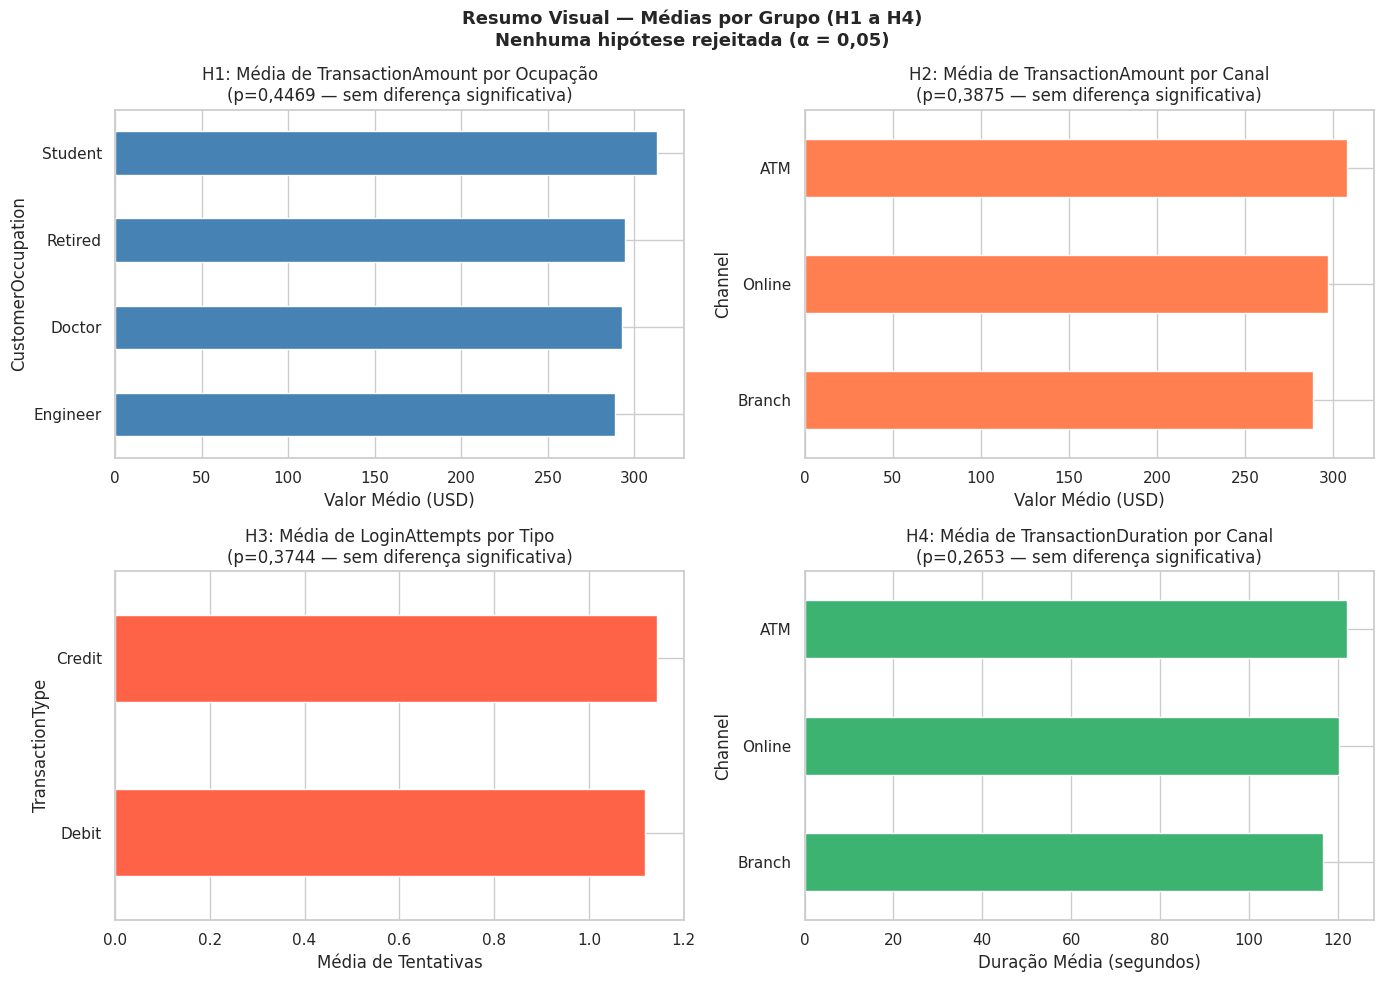

In [ ]:
# Gráfico de resumo — médias por grupo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby('CustomerOccupation', observed=True)['TransactionAmount'].mean().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('H1: Média de TransactionAmount por Ocupação\n(p=0,4469 — sem diferença significativa)')
axes[0,0].set_xlabel('Valor Médio (USD)')

df.groupby('Channel', observed=True)['TransactionAmount'].mean().sort_values().plot(
    kind='barh', ax=axes[0,1], color='coral', edgecolor='white')
axes[0,1].set_title('H2: Média de TransactionAmount por Canal\n(p=0,3875 — sem diferença significativa)')
axes[0,1].set_xlabel('Valor Médio (USD)')

df.groupby('TransactionType', observed=True)['LoginAttempts'].mean().sort_values().plot(
    kind='barh', ax=axes[1,0], color='tomato', edgecolor='white')
axes[1,0].set_title('H3: Média de LoginAttempts por Tipo\n(p=0,3744 — sem diferença significativa)')
axes[1,0].set_xlabel('Média de Tentativas')

df.groupby('Channel', observed=True)['TransactionDuration'].mean().sort_values().plot(
    kind='barh', ax=axes[1,1], color='mediumseagreen', edgecolor='white')
axes[1,1].set_title('H4: Média de TransactionDuration por Canal\n(p=0,2653 — sem diferença significativa)')
axes[1,1].set_xlabel('Duração Média (segundos)')

plt.suptitle('Resumo Visual — Médias por Grupo (H1 a H4)\nNenhuma hipótese rejeitada (α = 0,05)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Conclusões

### 5.1 Síntese dos Resultados

Este trabalho aplicou técnicas de **Análise Exploratória de Dados (EDA)**, **imputação de dados faltantes** e **Análise de Variância (ANOVA one-way)** sobre um dataset de 2.512 transações bancárias simuladas, com o objetivo de identificar padrões estatisticamente relevantes que possam estar associados a comportamentos potencialmente fraudulentos.

### 5.2 Sobre a Qualidade dos Dados

O dataset apresentou **ausência total de valores nulos e registros duplicados**, dispensando a necessidade de imputação.

A análise exploratória revelou que **apenas 4,9% das transações** apresentaram `LoginAttempts > 1`, sinalizando uma pequena parcela de acessos com múltiplas tentativas que, em um contexto real, mereceriam investigação mais aprofundada.

### 5.3 Resultados da ANOVA

Os quatro testes realizados produziram resultados consistentes:

| Hipótese | Variável | Grupo | F | p-value | Decisão |
|---|---|---|---|---|---|
| H1 | TransactionAmount | CustomerOccupation | 0,8872 | 0,4469 | Não rejeita H₀ |
| H2 | TransactionAmount | Channel | 0,9483 | 0,3875 | Não rejeita H₀ |
| H3 | LoginAttempts | TransactionType | 0,7893 | 0,3744 | Não rejeita H₀ |
| H4 | TransactionDuration | Channel | 1,3277 | 0,2653 | Não rejeita H₀ |

Em todos os casos, os valores de F próximos a 1,0 e p-values superiores a 0,25 indicam que a variação **entre grupos** é praticamente equivalente à variação **dentro dos grupos**, confirmando estatisticamente a ausência de diferenças significativas.

O pressuposto de **homocedasticidade** (Levene) foi satisfeito em todas as hipóteses (p > 0,32 em todos os casos), validando a aplicação da ANOVA mesmo diante da violação da normalidade — situação amparada pela robustez do método para amostras com n > 30 por grupo.

### 5.4 Interpretação e Implicações

O conjunto dos resultados sugere que **o dataset apresenta homogeneidade nas variáveis analisadas entre os grupos definidos**. Isso é coerente com a natureza sintética do dataset, que foi gerado de forma a não diferenciar sistematicamente os valores por perfil de cliente ou canal.

Do ponto de vista de **segurança bancária**, as implicações práticas são:

- A **ocupação profissional** não é, por si só, um preditor do valor transacionado — sistemas de alerta baseados apenas nessa variável teriam baixa eficácia;
- O **canal de acesso** (ATM, Online, Branch) não discrimina nem o valor nem a duração das transações, indicando que o comportamento dos clientes é homogêneo entre canais;
- As **tentativas de login** ocorrem de forma similar em transações de crédito e débito, sugerindo que acessos suspeitos não estão concentrados em um tipo específico de operação.

### 5.5 Limitações do Estudo

- **Dataset sintético:** os dados foram gerados de forma simulada, sem rótulo real de fraude (`IsFraud`), o que impede análises supervisionadas e pode explicar a ausência de diferenças significativas;
- **Escopo estatístico:** a análise foi restrita a métodos descritivos e inferenciais (ANOVA), sem uso de modelos preditivos;
- **Tamanho amostral moderado:** com 2.512 registros, eventuais efeitos pequenos podem não ter sido detectados;
- **Variável `LoginAttempts`:** por ser discreta e concentrada em um único valor, a ANOVA não é o método ideal — testes não-paramétricos (Mann-Whitney) seriam mais adequados.